# CNN vs FNO — Gravitational Lensing Image Classification
## GSoC Task: Model Comparison

**Dataset classes:** No Substructure · Subhalo · Vortex

> **Required weight files in working directory:**
> - `best_lensing_model.pth`  ← CNN weights
> - `best_fno_model.pth`      ← FNO weights

In [12]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import warnings

warnings.filterwarnings('ignore')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

DATA_DIR = './dataset'
CNN_WEIGHTS_PATH = '/best_cnn.pth'
FNO_WEIGHTS_PATH = '/best_fno.pth'

Using device: cuda


## 1. Defining the Architectures
We must recreate the exact architectures used during training so that `torch.load()` can successfully map the saved `.pth` weights to the network parameters. 

The ResNet18 is modified to accept 1-channel grayscale inputs, and the FNO is built using `SpectralConv2d` layers that perform global convolutions via Fast Fourier Transforms (FFTs).

In [13]:
def get_cnn_model():
    model = models.resnet18(weights=None) 
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    # Modify for 3 classes
    model.fc = nn.Linear(model.fc.in_features, 3)
    return model


#  FNO Definition

class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels, self.out_channels = in_channels, out_channels
        self.modes1, self.modes2 = modes1, modes2
        scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))

    def compl_mul2d(self, inp, weights):
        return torch.einsum("bixy,ioxy->boxy", inp, weights)

    def forward(self, x):
        B, C, H, W = x.shape
        x_ft = torch.fft.rfft2(x)
        out_ft = torch.zeros(B, self.out_channels, H, x_ft.shape[-1], dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes1, :self.modes2] = self.compl_mul2d(x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2] = self.compl_mul2d(x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)
        return torch.fft.irfft2(out_ft, s=(H, W))

class FNOBlock2d(nn.Module):
    def __init__(self, channels, modes1, modes2):
        super().__init__()
        self.spectral = SpectralConv2d(channels, channels, modes1, modes2)
        self.bypass   = nn.Conv2d(channels, channels, 1)
        self.norm     = nn.InstanceNorm2d(channels)

    def forward(self, x):
        return F.gelu(self.norm(self.spectral(x) + self.bypass(x)))

class FNOClassifier(nn.Module):
    def __init__(self, in_channels=1, num_classes=3, width=32, modes1=16, modes2=16, depth=4):
        super().__init__()
        self.lift = nn.Conv2d(in_channels, width, 1)
        self.blocks = nn.Sequential(*[FNOBlock2d(width, modes1, modes2) for _ in range(depth)])
        self.pool = nn.AdaptiveAvgPool2d(4)
        hidden = width * 4 * 4
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.lift(x)
        x = self.blocks(x)
        x = self.pool(x)
        return self.head(x)

## 2. Dual Preprocessing DataLoader
This custom dataset targets the `/val` directory. For every `.npy` file it reads, it outputs two distinct tensors:
1. `img_cnn`: Min-max normalized.
2. `img_fno`: Log1p tone-mapped and bilinearly interpolated to $150 \times 150$.

In [14]:
class DualLensingDataset(Dataset):
    def __init__(self, root_dir, split='val'):
        self.root_dir = os.path.join(root_dir, split)
        self.classes = ['no', 'sphere', 'vort']
        self.file_list = []

        for idx, cls in enumerate(self.classes):
            cls_path = os.path.join(self.root_dir, cls)
            if not os.path.exists(cls_path): continue
            for f in os.listdir(cls_path):
                if f.endswith('.npy'):
                    self.file_list.append((os.path.join(cls_path, f), idx))

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_path, label = self.file_list[idx]
        raw_img = np.load(file_path).astype(np.float32)

        # CNN Preprocessing (Min-Max only)
        img_cnn = (raw_img - raw_img.min()) / (raw_img.max() - raw_img.min() + 1e-8)
        img_cnn = torch.tensor(img_cnn)
        if len(img_cnn.shape) == 2:
            img_cnn = img_cnn.unsqueeze(0)

        #  FNO Preprocessing 
        img_fno = raw_img.copy()
        if img_fno.ndim == 3:
            img_fno = img_fno[..., 0] if img_fno.shape[-1] <= 4 else img_fno[0]
        
        mn, mx = img_fno.min(), img_fno.max()
        if mx - mn > 1e-8:
            img_fno = (img_fno - mn) / (mx - mn)
            
        s = 10.0
        img_fno = np.log1p(img_fno * s) / np.log1p(s)
        
        t_fno = torch.tensor(img_fno, dtype=torch.float32).unsqueeze(0)
        img_fno = F.interpolate(t_fno.unsqueeze(0), size=(150, 150), mode='bilinear', align_corners=False).squeeze(0)

        return img_cnn, img_fno, label

val_ds = DualLensingDataset(DATA_DIR, split='val')
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
print(f"Loaded {len(val_ds)} validation images for comparison.")

Loaded 7500 validation images for comparison.


## 3. Evaluation Loop
We initialize both models, load their respective pre-trained weights, and pass our dual-processed validation batches through them sequentially under `torch.no_grad()`.

In [15]:
# Initialize and load models
cnn_model = get_cnn_model().to(DEVICE)
cnn_model.load_state_dict(torch.load(CNN_WEIGHTS_PATH, map_location=DEVICE))
cnn_model.eval()

fno_model = FNOClassifier(width=32, modes1=16, modes2=16, depth=4).to(DEVICE)
fno_model.load_state_dict(torch.load(FNO_WEIGHTS_PATH, map_location=DEVICE))
fno_model.eval()

cnn_all_probs, fno_all_probs, all_labels = [], [], []

print("Running evaluation on both models...")
with torch.no_grad():
    for img_cnn, img_fno, labels in val_loader:
        labels = labels.to(DEVICE)
        
        # CNN Forward
        img_cnn = img_cnn.to(DEVICE)
        out_cnn = cnn_model(img_cnn)
        prob_cnn = torch.softmax(out_cnn, dim=1)
        cnn_all_probs.append(prob_cnn.cpu().numpy())
        
        # FNO Forward
        img_fno = img_fno.to(DEVICE)
        out_fno = fno_model(img_fno)
        prob_fno = torch.softmax(out_fno, dim=1)
        fno_all_probs.append(prob_fno.cpu().numpy())
        
        all_labels.append(labels.cpu().numpy())

cnn_all_probs = np.concatenate(cnn_all_probs)
fno_all_probs = np.concatenate(fno_all_probs)
all_labels = np.concatenate(all_labels)

print("Evaluation complete.")

Running evaluation on both models...
Evaluation complete.


## 4. Visualizing the Comparison
Using a One-vs-Rest strategy, we plot the ROC curves and calculate the Macro-AUC for both the standard CNN and the Neural Operator.

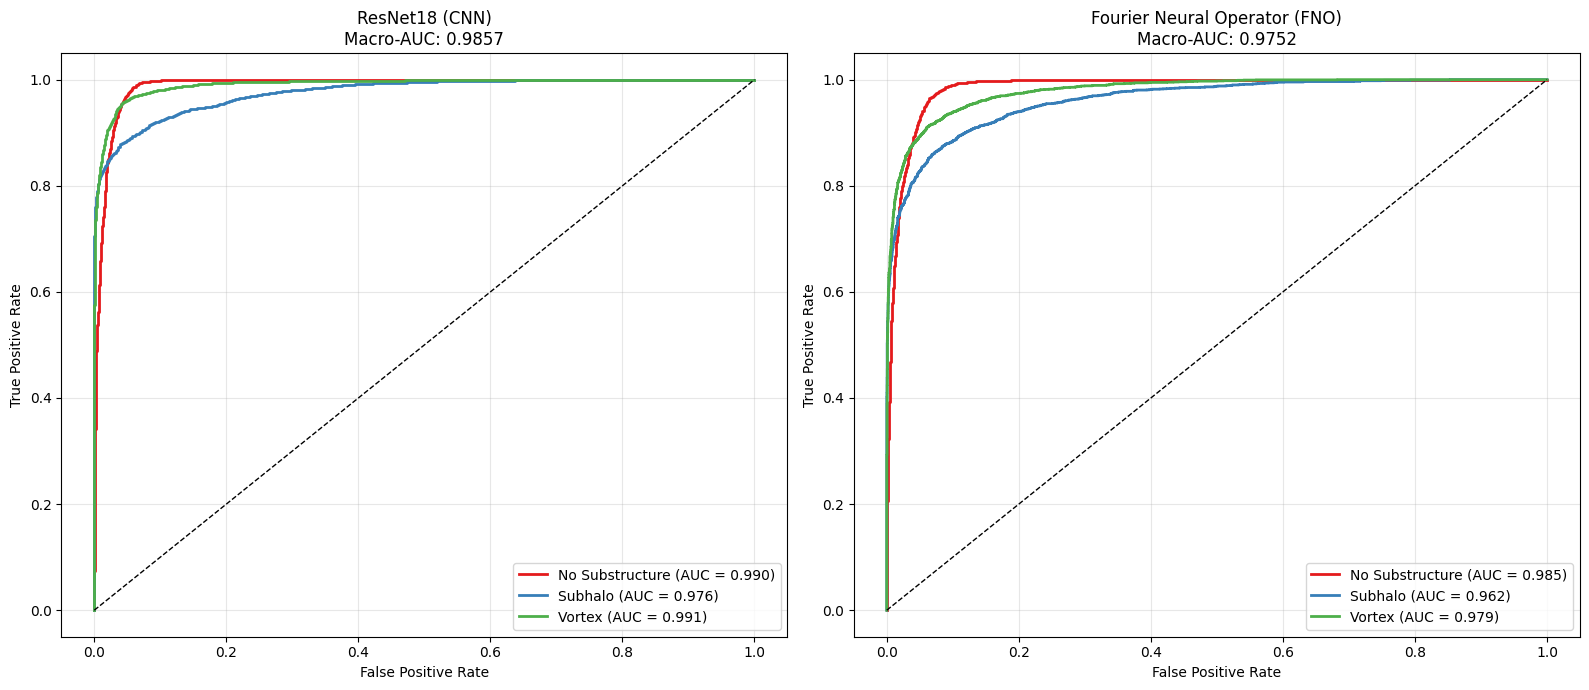

=== Final Results ===
ResNet18 Macro AUC: 0.9857
FNO Macro AUC:      0.9752


In [16]:
y_test = label_binarize(all_labels, classes=[0, 1, 2])
class_names = ['No Substructure', 'Subhalo', 'Vortex']
colors = ['#e41a1c', '#377eb8', '#4daf4a']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# helper function to plot ROC for a specific model
def plot_model_roc(ax, probs, title):
    macro_auc = []
    for i in range(3):
        fpr, tpr, _ = roc_curve(y_test[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        macro_auc.append(roc_auc)
        ax.plot(fpr, tpr, color=colors[i], lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.3f})')
        
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{title}\nMacro-AUC: {np.mean(macro_auc):.4f}')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    return np.mean(macro_auc)

# Plot CNN
cnn_macro = plot_model_roc(axes[0], cnn_all_probs, "ResNet18 (CNN)")

# Plot FNO
fno_macro = plot_model_roc(axes[1], fno_all_probs, "Fourier Neural Operator (FNO)")

plt.tight_layout()
plt.savefig("cnn_vs_fno_comparison.png", dpi=150)
plt.show()

print("=== Final Results ===")
print(f"ResNet18 Macro AUC: {cnn_macro:.4f}")
print(f"FNO Macro AUC:      {fno_macro:.4f}")